# 04 · Coherence, single shots, and feedback

Part 3 fitted a pi pulse from a Rabi scan. Everything here needs that one tool. Once you can put
the qubit in $|1\rangle$ on demand, you can ask how long it stays there.

This part measures the three numbers that go on every device datasheet, then stops averaging and
looks at individual shots, then uses one shot to decide what the program does next:

- **T1**, energy relaxation, from an inversion recovery scan.
- **T2\***, dephasing, from a Ramsey fringe with a deliberately detuned drive.
- **T2**, dephasing after refocusing, from a Hahn echo.
- **Single-shot readout**: two blobs in the IQ plane, a threshold, and the error it costs you.
- **Active reset**: measure, and fire a pi pulse only if the qubit came up hot.

Three QProgram features arrive because these experiments need them: **fragments** (reusable pulse
blocks), the three **measurement fields**, and **conditionals** driven by a measured state.

In [1]:
# Run me first. A no-op when qprogram is already installed, an install when it is not
# (a fresh Google Colab runtime, for example).
try:
    import qprogram  # noqa: F401
except ImportError:
    import subprocess
    import sys

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "qprogram[viz]==0.1.0", "scipy"],
        check=True,
    )
    import qprogram  # noqa: F401

from importlib.metadata import version

print("qprogram", version("qprogram"))

qprogram 0.1.0


## 4.0 The device under test

Same simulated chip as the other parts, same numbers. `DEVICE` holds the truth the fits have to
recover: `q0_T1`, `q0_T2star`, and `q0_T2echo`. The measurement models read the whole dict, because
they stand in for the fridge.

The programs read two of its entries, and both are numbers a real experiment would already have on
hand: `q0_f01`, which Part 3's two-tone scan measured, and `q0_a_pi`, which its Rabi fit recovered
to about 0.2 percent. Taking the device values rather than carrying the fitted ones across notebooks
keeps this one runnable on its own. `DETUNING` is a deliberate mistake. The drive sits 400 kHz above
the qubit, so the Ramsey fringe has something to show.

In [2]:
import math

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

import qprogram as qp
from qprogram import MeasurementField as MF
from qprogram import fragment
from qprogram.buses import BusSchema
from qprogram.waveforms import IQDrag, IQPair, Square

DEVICE = {
    "q0_f01": 4.85e9,  # Hz, at the flux sweet spot
    "q0_a_pi": 0.62,  # drive amplitude of a pi pulse (DAC units)
    "q0_T1": 18_000,  # ns
    "q0_T2star": 9_000,  # ns
    "q0_T2echo": 16_000,  # ns
}
DETUNING = 0.4e6  # Hz, how far off the drive frequency is set on purpose

A_PI = DEVICE["q0_a_pi"]
DRIVE_FREQ = DEVICE["q0_f01"] + DETUNING

schema = BusSchema.transmon()
q = schema.q

print(f"pi amplitude {A_PI}, drive set to {DRIVE_FREQ / 1e9:.6f} GHz")
print("truth to recover:", {k: v for k, v in DEVICE.items() if k.startswith("q0_T")})

pi amplitude 0.62, drive set to 4.850400 GHz
truth to recover: {'q0_T1': 18000, 'q0_T2star': 9000, 'q0_T2echo': 16000}


## 4.1 Fragments: the same three moves, a different middle

Every experiment in this part is the same shape. Put the qubit somewhere. Wait. Read it out. Only
the middle changes.

Copy-pasting the pulse lines into three programs is how calibration code rots. Someone fixes the
DRAG `beta` in two of them and forgets the third, and a week later two experiments disagree for a
reason nobody can find. A `Fragment` is a named, parameterized sub-program. Write the pulse once,
call it everywhere.

Three rules for the `@fragment` decorator:

- The **first argument is the builder**. Every other argument becomes a `Parameter`, in order, and
  the fragment's name is the function's name.
- Parameters are **untyped placeholders**. A parameter can stand for a number, a bus, or a
  waveform; what you pass at the call site decides. `x90` below puts one in arithmetic
  (`amp / 2`), and `drive` goes straight into a bus position.
- The body runs **once, at decoration time**, to record the AST. A Python `if` inside it is
  evaluated then, not per call. This is a template, not a function you call at runtime.

In [3]:
@fragment
def x180(f, drive, amp):
    """A pi pulse: the DRAG shape Part 3 calibrated. `f` is the fragment builder."""
    f.play(drive, IQDrag(amplitude=amp, duration=40, sigma=10, beta=0.1))


@fragment
def x90(f, drive, amp):
    """A pi/2 pulse: same shape, half the area. `amp` is still the *pi* amplitude."""
    f.play(drive, IQDrag(amplitude=amp / 2, duration=40, sigma=10, beta=0.1))


print(x180)
print(x90)

demo = qp.QProgram(label="fragment_demo", schema=schema)
demo.call(x180, q[0].drive, A_PI)  # positional
demo.call(x90, q[0].drive, amp=A_PI)  # or by keyword, Python's own binding rules
print(qp.dumps(demo))

Fragment('x180', params=(drive, amp))
Fragment('x90', params=(drive, amp))
#!QProgram 1.0

metadata:
  label: "fragment_demo"

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires

fragment x180(drive, amp):
  play drive IQDrag(amplitude=amp, duration=40, sigma=10, beta=0.1)

fragment x90(drive, amp):
  play drive IQDrag(amplitude=(amp / 2), duration=40, sigma=10, beta=0.1)

body:
  x180(q[0].drive, 0.62)
  x90(q[0].drive, 0.62)



Two things to read off that text. Definitions come out as `fragment` sections before `body:`, and
call sites stay call sites: `x180(q[0].drive, 0.62)` is one AST node, not an inlined copy. The
expression survives too, as `IQDrag(amplitude=(amp / 2), ...)`.

`expand()` is the lowering. It returns a new program with every call replaced by a plain `block:`
holding the substituted body. Validation and execution do this for you, so you rarely call it,
but it is the thing to print when you want to see what a compiler will get. Substitution puts the
bound value where the parameter was and stops there, so the expanded pi/2 pulse reads
`amplitude=(0.62 / 2)`. The arithmetic is still described rather than folded, so a compiler can
decide where to evaluate it.

Measurements inside a fragment come with one catch, and the cell after next shows it. A
measurement's auto-generated name normally embeds its bus (`q0/readout/m0`). Inside a fragment the
bus is still a parameter, so there is no bus to embed and the name is a plain `m0`. Repeated calls
get suffixed at expansion (`m0`, `m0_2`) so nothing collides. The handle also lives inside the
fragment, not in your notebook, so `measurement_handles()` on the host program shows nothing until
you expand.

In [4]:
flat = demo.expand()

print("fragments registered on the program:", list(demo.fragments))
print("fragments after expand():", list(flat.fragments))
print()
print(qp.dumps(flat))

fragments registered on the program: ['x180', 'x90']
fragments after expand(): []

#!QProgram 1.0

metadata:
  label: "fragment_demo"

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires

body:
  block:
    play q[0].drive IQDrag(amplitude=0.62, duration=40, sigma=10, beta=0.1)
  block:
    play q[0].drive IQDrag(amplitude=(0.62 / 2), duration=40, sigma=10, beta=0.1)



In [5]:
@fragment
def readout_block(f, ro):
    """Play the readout tone and integrate it."""
    f.play(ro, IQPair(Square(0.2, 2000), Square(0.0, 2000)))
    f.measure(ro, "readout", "weights", fields=(MF.IQ, MF.STATE))


read_demo = qp.QProgram(label="readout_demo", schema=schema)
read_demo.call(readout_block, q[0].readout)
read_demo.call(readout_block, q[0].readout)

print("handles before expand:", [h.name for h in read_demo.measurement_handles()])
print("handles after expand: ", [h.name for h in read_demo.expand().measurement_handles()])

handles before expand: []
handles after expand:  ['m0', 'm0_2']


Fragments carry the pulses, `measure` stays in the host program. That way the handle stays an
ordinary Python variable and `result.get(m)` reads the way you wrote it. Every experiment below
follows that rule.

## 4.2 T1: inversion recovery

Excite the qubit, wait, look. Sweep the wait and the excited-state population decays as

$$P_1(t) = e^{-t/T_1}.$$

One honest warning first, and it applies to the whole part. **The reference executor has no timing
model.** `wait` and `sync` change nothing about the numbers that come back. The delay shows up in
the result only because the measurement model reads `env["delay"]`, and `env` is the dict of
currently bound loop variables. The program is real, the loop is real, the physics is a lambda.

In [6]:
t1 = qp.QProgram(label="t1", description="inversion recovery on q0", schema=schema)
delay = t1.variable("delay", label="Delay", units="ns")
t1_delays = qp.Range(0, 60_000, 1500)  # Range includes its stop value, so 0 to 60000 in 41 steps

with t1.average(shots=400):  # 41 points x 400 shots = 16k shots, well under a second
    with t1.sweep(delay, t1_delays):
        t1.set_frequency(q[0].drive, DEVICE["q0_f01"])
        t1.call(x180, q[0].drive, A_PI)
        t1.wait(q[0].drive, delay)
        t1.sync()
        m_t1 = t1.measure(q[0].readout, "readout", "weights", fields=(MF.STATE, MF.IQ, MF.RAW))

delays = np.array(t1_delays.values())
print(f"{len(delays)} delays from {delays[0]:.0f} to {delays[-1]:.0f} ns")
print("measurement:", m_t1.name)

41 delays from 0 to 60000 ns
measurement: q0/readout/m0


The model plays the part of the qubit and of the readout chain. Two callables:

- `p_excited` is the probability that a shot is classified as $|1\rangle$. It drives the `state`
  field.
- `response` is the noiseless IQ point. A dispersive readout puts $|0\rangle$ and $|1\rangle$ at
  two places in the IQ plane, and the average over shots lands on the line between them, at the
  fraction given by the population. `blob` computes exactly that.

`noise=0.4` is per-shot gaussian noise on each quadrature, so the averaged IQ point carries the
shot noise you would actually fight in the lab.

`average(shots=400)` adds no dimension to the result. The `state` field comes back as the fraction
of shots classified as excited. The population itself, one number per delay.

In [7]:
GROUND = -1.0 - 0.4j  # where a |0> shot lands in the IQ plane
EXCITED = 1.0 + 0.4j  # where a |1> shot lands
AXIS = (EXCITED - GROUND) / abs(EXCITED - GROUND)  # the unit vector between them


def blob(p):
    """The shot-averaged IQ point for an excited-state population `p`."""
    return GROUND + p * (EXCITED - GROUND)


def p_t1(bus, env):
    """T1 (inversion recovery), delay in ns."""
    return np.exp(-env["delay"] / DEVICE["q0_T1"])


t1_result = qp.simulate(
    t1,
    model=qp.MockMeasurementModel(
        response=lambda bus, env: blob(p_t1(bus, env)),
        p_excited=p_t1,
        noise=0.4,
        raw_samples=16,
        seed=17,
    ),
)
population = t1_result.get(m_t1, field=MF.STATE)
print("state field:", population.dims, population.shape)
print("first three points:", np.round(population.values[:3], 3))

state field: ('delay',) (41,)
first three points: [1.    0.912 0.878]


fitted T1 = 18.00 us   true = 18.00 us


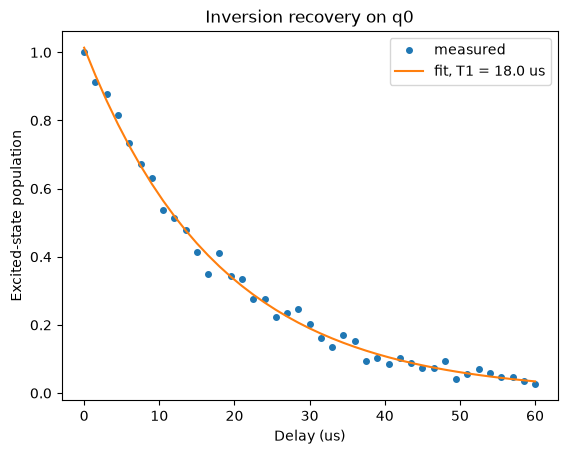

In [8]:
# Fit an exponential with a free offset and read T1 off it.
def decay(t, amplitude, tau, offset):
    return amplitude * np.exp(-t / tau) + offset


popt, _ = curve_fit(decay, delays, population.values, p0=[1.0, 10_000.0, 0.0])
t1_fit = popt[1]
print(f"fitted T1 = {t1_fit / 1000:.2f} us   true = {DEVICE['q0_T1'] / 1000:.2f} us")

plt.plot(delays / 1000, population.values, "o", ms=4, label="measured")
plt.plot(delays / 1000, decay(delays, *popt), "-", label=f"fit, T1 = {t1_fit / 1000:.1f} us")
plt.xlabel("Delay (us)")
plt.ylabel("Excited-state population")
plt.title("Inversion recovery on q0")
plt.legend()
plt.show()

## 4.3 Ramsey: T2\* and the frequency you got wrong

T1 does not care what your drive frequency is. Dephasing does.

A Ramsey sequence is two pi/2 pulses with a gap. The first one puts the qubit on the equator, it
precesses at the difference between your drive frequency and the qubit, and the second one turns
that accumulated phase into a population. The result is a fringe at the detuning, dying out at the
dephasing time:

$$P_1(t) = \tfrac{1}{2}\left(1 + \cos(2\pi \delta t)\right) e^{-t/T_2^*}.$$

The drive is set 400 kHz high on purpose (`DRIVE_FREQ`), so the fringe has a period of 2.5 us. The
sweep steps 125 ns, twenty points per period.

In [9]:
ramsey = qp.QProgram(label="ramsey", description="Ramsey fringe on q0", schema=schema)
r_delay = ramsey.variable("delay", label="Delay", units="ns")

with ramsey.average(shots=400):
    with ramsey.sweep(r_delay, qp.Range(0, 20_000, 125)):
        ramsey.set_frequency(q[0].drive, DRIVE_FREQ)  # deliberately 400 kHz off
        ramsey.call(x90, q[0].drive, A_PI)
        ramsey.wait(q[0].drive, r_delay)
        ramsey.call(x90, q[0].drive, A_PI)
        ramsey.sync()
        m_ramsey = ramsey.measure(q[0].readout, "readout", "weights", fields=(MF.STATE,))


def p_ramsey(bus, env):
    """Ramsey with an intentional detuning and exponential decay."""
    t = env["delay"]
    return 0.5 * (1.0 + np.cos(2 * np.pi * DETUNING * t * 1e-9)) * np.exp(-t / DEVICE["q0_T2star"])


ramsey_result = qp.simulate(ramsey, model=qp.MockMeasurementModel(p_excited=p_ramsey, seed=23))
fringe = ramsey_result.get(m_ramsey, field=MF.STATE)
r_delays = fringe.coords["delay"].values
print(f"{len(r_delays)} points, {r_delays[-1] / 1000:.0f} us long, {fringe.dims} {fringe.shape}")

161 points, 20 us long, ('delay',) (161,)


Four parameters to fit: amplitude, $T_2^*$, the fringe frequency, and a phase. A least-squares fit
of a cosine needs a decent starting frequency or it walks into a local minimum, so take that guess
from the spectrum of the data instead of typing a number.

Note the fit function has no constant offset. In this model both the fringe and the mean decay
with the same time constant, so the curve relaxes to zero rather than to one half. Fit the model
you believe in, not the one you memorised.

The fringe frequency is the practical output. It is the error in your drive frequency, and
subtracting it is how a qubit gets tuned up. Run Ramsey, correct, run it again with a longer sweep
and a smaller residual detuning. A lab person will ask about one caveat. A single Ramsey gives the
*magnitude* of the detuning, not its sign, because $\cos$ is even. You get the sign by moving the
drive a known amount and seeing whether the fringe speeds up or slows down.

FFT guess          = 397.5 kHz
fitted T2*         = 9.03 us   true = 9.00 us
fitted detuning    = 399.8 kHz   true = 400.0 kHz


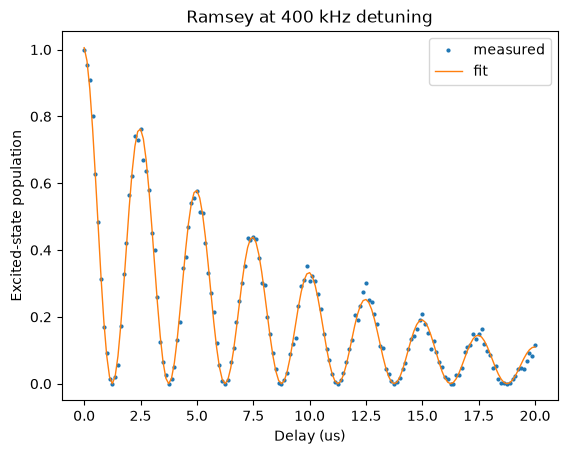

In [10]:
def fringe_model(t, amplitude, tau, freq, phase):
    return amplitude * np.exp(-t / tau) * (1.0 + np.cos(2 * np.pi * freq * t * 1e-9 + phase))


spectrum = np.abs(np.fft.rfft(fringe.values - fringe.values.mean()))
freq_axis = np.fft.rfftfreq(len(r_delays), d=(r_delays[1] - r_delays[0]) * 1e-9)
freq_guess = freq_axis[spectrum.argmax()]

popt, _ = curve_fit(fringe_model, r_delays, fringe.values, p0=[0.5, 8000.0, freq_guess, 0.0])
t2star_fit, detuning_fit = popt[1], popt[2]
print(f"FFT guess          = {freq_guess / 1e3:.1f} kHz")
print(f"fitted T2*         = {t2star_fit / 1000:.2f} us   true = {DEVICE['q0_T2star'] / 1000:.2f} us")
print(f"fitted detuning    = {detuning_fit / 1e3:.1f} kHz   true = {DETUNING / 1e3:.1f} kHz")

plt.plot(r_delays / 1000, fringe.values, ".", ms=4, label="measured")
plt.plot(r_delays / 1000, fringe_model(r_delays, *popt), "-", lw=1, label="fit")
plt.xlabel("Delay (us)")
plt.ylabel("Excited-state population")
plt.title(f"Ramsey at {detuning_fit / 1e3:.0f} kHz detuning")
plt.legend()
plt.show()

In [11]:
corrected = DRIVE_FREQ - detuning_fit
print(f"drive was at   {DRIVE_FREQ / 1e9:.6f} GHz")
print(f"corrected to   {corrected / 1e9:.6f} GHz")
print(f"true f01 is    {DEVICE['q0_f01'] / 1e9:.6f} GHz")
print(f"residual error {(corrected - DEVICE['q0_f01']) / 1e3:+.1f} kHz")

drive was at   4.850400 GHz
corrected to   4.850000 GHz
true f01 is    4.850000 GHz
residual error +0.2 kHz


## 4.4 Hahn echo: refocusing the slow noise

$T_2^*$ mixes two things. Real dephasing, and the fact that the qubit frequency wanders between
shots. A pi pulse in the middle of the delay swaps the two states, so phase picked up in the first
half is unwound in the second. Anything slower than the sequence cancels. What is left is $T_2$,
and it is longer:

$$P_1(t) = \tfrac{1}{2} + \tfrac{1}{2} e^{-t/T_2}.$$

The sequence is x90, wait $t/2$, x180, wait $t/2$, x90. You have the pieces already. The fragments
from 4.1, and `wait` with an expression (`delay / 2` is a perfectly good duration, and it
serializes as `wait q[0].drive (delay / 2)`).

### 🧩 Exercise 4.1: measure T2 with an echo

Build the echo experiment and fit $T_2$.

1. New program, one variable `delay` (the model reads `env["delay"]`, so the name matters).
2. `average(shots=600)` around `sweep(delay, qp.Range(0, 40_000, 800))`, 51 points.
3. Inside: `x90`, `wait(delay / 2)`, `x180`, `wait(delay / 2)`, `x90`, `sync`, then `measure` with
   `fields=(MF.STATE,)`.
4. Run it with the `p_echo` model written out in the stub, `seed=31`, and fit
   `0.5 + amplitude * exp(-t / tau)`.

Fix the offset at 0.5 rather than fitting it. With the detuning refocused the curve relaxes to the
fully mixed value, and you know that number without measuring it. Leave it free and it trades
against `tau`: the two come out about 90 percent anti-correlated, and the error bar on $T_2$ roughly
triples for nothing. Pinning what you know is not cheating, it is how you get a number you can
quote.

The plot and the comparison table two cells down read `echo_amp` and `t2_fit` from your solution.

In [ ]:
# TODO: measure T2 with a Hahn echo.
#
# def p_echo(bus, env):
#     return 0.5 + 0.5 * np.exp(-env["delay"] / DEVICE["q0_T2echo"])
#
# 1) echo = qp.QProgram(label="hahn_echo", schema=schema); e_delay = echo.variable("delay", ...)
# 2) with echo.average(shots=600): with echo.sweep(e_delay, qp.Range(0, 40_000, 800)):
# 3) x90 / wait(e_delay / 2) / x180 / wait(e_delay / 2) / x90 / sync / measure(fields=(MF.STATE,))
# 4) echo_result = qp.simulate(echo, model=qp.MockMeasurementModel(p_excited=p_echo, seed=31))
# 5) echo_data = echo_result.get(m_echo, field=MF.STATE); e_delays = echo_data.coords["delay"].values
# 6) curve_fit(lambda t, amplitude, tau: 0.5 + amplitude * np.exp(-t / tau), ...)
#
# Leave the fitted amplitude and time constant in `echo_amp` and `t2_fit`, the data in
# `echo_data`, and the delays in `e_delays`. The next cell reads them.

Plot it, then put the three numbers next to each other. The ordering $T_2^* < T_2 < 2T_1$ is the
sanity check you run before believing any of it. Refocusing can only help, and no dephasing time
can beat twice the relaxation time.

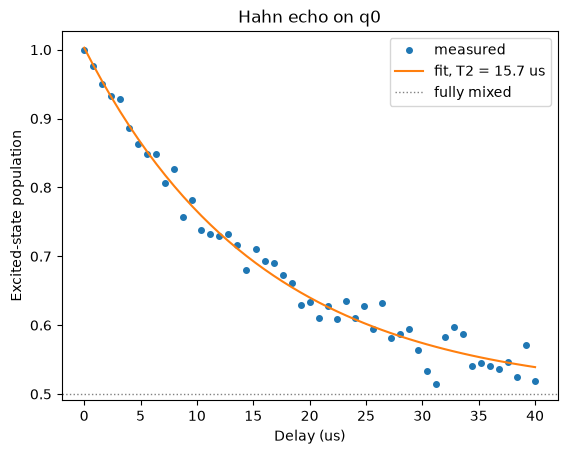

quantity         fitted        true    error
T1             18.00 us    18.00 us    -0.0%
T2*             9.03 us     9.00 us     0.4%
T2 (echo)      15.65 us    16.00 us    -2.2%

T2* < T2 < 2*T1 holds: True


In [13]:
plt.plot(e_delays / 1000, echo_data.values, "o", ms=4, label="measured")
plt.plot(
    e_delays / 1000,
    0.5 + echo_amp * np.exp(-e_delays / t2_fit),
    "-",
    label=f"fit, T2 = {t2_fit / 1000:.1f} us",
)
plt.axhline(0.5, color="grey", ls=":", lw=1, label="fully mixed")
plt.xlabel("Delay (us)")
plt.ylabel("Excited-state population")
plt.title("Hahn echo on q0")
plt.legend()
plt.show()

rows = [
    ("T1", t1_fit, DEVICE["q0_T1"]),
    ("T2*", t2star_fit, DEVICE["q0_T2star"]),
    ("T2 (echo)", t2_fit, DEVICE["q0_T2echo"]),
]
print(f"{'quantity':<11}{'fitted':>12}{'true':>12}{'error':>9}")
for name, fitted, true in rows:
    print(f"{name:<11}{fitted / 1000:>9.2f} us{true / 1000:>9.2f} us{100 * (fitted / true - 1):>8.1f}%")
print()
print(f"T2* < T2 < 2*T1 holds: {t2star_fit < t2_fit < 2 * t1_fit}")

## 4.5 The three measurement fields

The T1 program asked for all three fields:
`fields=(MF.STATE, MF.IQ, MF.RAW)`. One `measure` call, three arrays, three shapes. `field=`
picks one.

| field | shape | what it is |
|---|---|---|
| `MF.IQ` | `(*sweeps, IQ)` | integrated I and Q, averaged over shots. The default. |
| `MF.STATE` | `(*sweeps)` | classified 0/1 per shot, averaged into a population. |
| `MF.RAW` | `(*sweeps, time, IQ)` | the ADC trace, averaged over shots. |

`result.get(m)` defaults to `MF.IQ` and raises `KeyError` for a field the measurement never
requested. It never quietly hands you a different array, which matters. A `state` array returned
where the caller expected IQ would look like data all the way downstream.

In [14]:
for field in (MF.IQ, MF.STATE, MF.RAW):
    array = t1_result.get(m_t1, field=field)
    print(f"{field:<6} dims={array.dims!s:<26} shape={array.shape}")

no_iq = qp.QProgram(schema=schema)
m_state_only = no_iq.measure(q[0].readout, "readout", "weights", fields=(MF.STATE,))
try:
    qp.simulate(no_iq, model=qp.MockMeasurementModel()).get(m_state_only)
except KeyError as exc:
    print("bare get() on a state-only measurement:", exc)

iq     dims=('delay', 'IQ')            shape=(41, 2)
state  dims=('delay',)                 shape=(41,)
raw    dims=('delay', 'time', 'IQ')    shape=(41, 16, 2)
bare get() on a state-only measurement: "Measurement 'q0/readout/m0' has no field 'iq'; available: state"


`state` and `iq` are two views of the same shots. The classifier already collapsed each shot to a
0 or a 1, so `state` is the population directly. `iq` needs projecting onto the line between the
two readout blobs before it means anything, and it carries the shot noise of the integration.

Both recover T1 to better than 2 percent. The state fit is the closer one here, because
classification has already thrown away the noise the projection still has to average over.

T1 from state = 18.00 us
T1 from iq    = 17.69 us


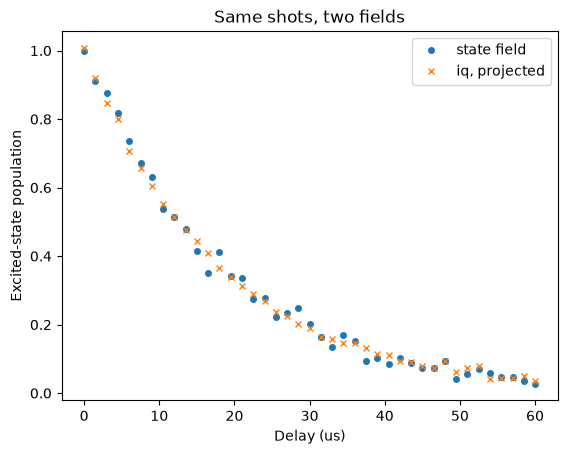

In [15]:
iq = t1_result.get(m_t1)  # default field
z = iq.sel(IQ="I").values + 1j * iq.sel(IQ="Q").values
projected = ((z - GROUND) * np.conj(AXIS)).real / abs(EXCITED - GROUND)

from_state, _ = curve_fit(decay, delays, population.values, p0=[1.0, 10_000.0, 0.0])
from_iq, _ = curve_fit(decay, delays, projected, p0=[1.0, 10_000.0, 0.0])
print(f"T1 from state = {from_state[1] / 1000:.2f} us")
print(f"T1 from iq    = {from_iq[1] / 1000:.2f} us")

plt.plot(delays / 1000, population.values, "o", ms=4, label="state field")
plt.plot(delays / 1000, projected, "x", ms=5, label="iq, projected")
plt.xlabel("Delay (us)")
plt.ylabel("Excited-state population")
plt.title("Same shots, two fields")
plt.legend()
plt.show()

## 4.6 Single-shot readout

`average(shots)` throws the individual shots away and hands you the mean. To see the shots
themselves, make the shot index a **sweep variable** and drop the average:

```python
with program.sweep(shot, qp.Range(0, 599, 1)):
    ...
```

That reads like a trick and it is not. The loop runs the sequence once per point, so every point
holds exactly one shot, and the result array gets a `shot` dimension of length 600. Nothing reads
the variable, and that is fine. A sweep variable that no operation uses still drives its loop. A
sequencer does exactly this when you ask it to stream every acquisition instead of accumulating.

The model changes too. Averaged IQ was one point on a line; single shots are two clouds. `sigma`
is the width of each cloud, and it is the whole story of readout fidelity.

Two programs, 600 single shots each. One reads out the qubit as it sits, the other puts a pi pulse
in front. The 2 percent that come out the wrong way in each are preparation error, and realistic.
A real pi pulse is never perfect and a real qubit is never perfectly cold.

In [16]:
class BlobModel:
    """Single-shot readout: two gaussian clouds in the IQ plane, `p1` of the shots in the upper one."""

    raw_samples = 16

    def __init__(self, p1, sigma=0.55, seed=3):
        self.p1, self.sigma = p1, sigma
        self.rng = np.random.default_rng(seed)

    def sample(self, bus, env):
        state = int(self.rng.random() < self.p1)
        center = EXCITED if state else GROUND
        return qp.MeasurementSample(
            i=center.real + self.rng.normal(0, self.sigma),
            q=center.imag + self.rng.normal(0, self.sigma),
            state=state,
            raw=np.zeros((self.raw_samples, 2)),
        )


one = BlobModel(p1=1.0, seed=0).sample("q0/readout", {})
print(f"one excited shot: I={one.i:+.2f} Q={one.q:+.2f} state={one.state} raw={one.raw.shape}")

one excited shot: I=+0.93 Q=+0.75 state=1 raw=(16, 2)


In [17]:
def single_shots(prepare_excited, n=600):
    program = qp.QProgram(label="single_shot", schema=schema)
    shot = program.variable("shot", label="Shot index")
    with program.sweep(shot, qp.Range(0, n - 1, 1)):  # one shot per point, no average
        if prepare_excited:
            program.call(x180, q[0].drive, A_PI)
        program.sync()
        handle = program.measure(q[0].readout, "readout", "weights", fields=(MF.IQ, MF.STATE))
    return program, handle


ground_program, m_ground = single_shots(prepare_excited=False)
excited_program, m_excited = single_shots(prepare_excited=True)

ground_run = qp.simulate(ground_program, model=BlobModel(p1=0.02, seed=5))
excited_run = qp.simulate(excited_program, model=BlobModel(p1=0.98, seed=6))
ground, excited = ground_run.get(m_ground), excited_run.get(m_excited)

# The model reports which state each shot really was in, so keep it: it is the answer key.
truth = np.concatenate(
    [
        ground_run.get(m_ground, field=MF.STATE).values,
        excited_run.get(m_excited, field=MF.STATE).values,
    ]
)
print("dims:", ground.dims, ground.shape)
print("no average, so each point is one shot:", np.round(ground.values[:3, 0], 2))
print(f"prepared wrong: {int(truth[:600].sum())} cold shots hot, {int(600 - truth[600:].sum())} hot shots cold")

dims: ('shot', 'IQ') (600, 2)
no average, so each point is one shot: [-1.73 -0.38 -1.43]
prepared wrong: 17 cold shots hot, 12 hot shots cold


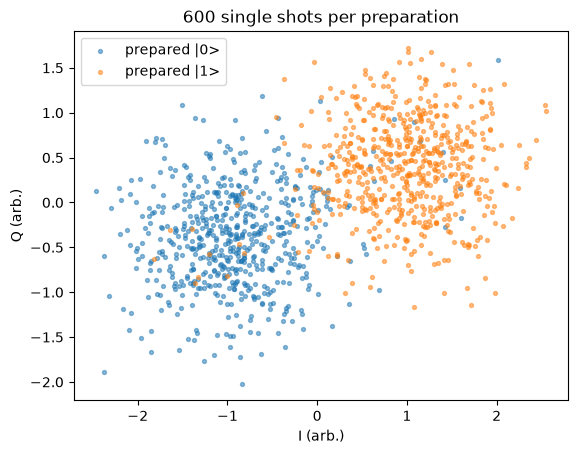

In [18]:
plt.scatter(ground.sel(IQ="I"), ground.sel(IQ="Q"), s=8, alpha=0.5, label="prepared |0>")
plt.scatter(excited.sel(IQ="I"), excited.sel(IQ="Q"), s=8, alpha=0.5, label="prepared |1>")
plt.xlabel("I (arb.)")
plt.ylabel("Q (arb.)")
plt.title("600 single shots per preparation")
plt.gca().set_aspect("equal")
plt.legend()
plt.show()

To turn a shot into a bit, project onto the line joining the two cloud centres and threshold at
the midpoint. The centres come from the data, not from the model. This is a calibration, and it is
the one you redo whenever the readout drifts.

Two error numbers come out of this, and they are not the same thing:

- The **measured** error: the threshold decision against what you prepared. That is all the lab
  has, and it charges readout for the preparation error too.
- The **assignment** error: the threshold decision against the state each shot was really in. The
  simulator knows, so you can price the readout on its own. For two gaussian clouds separated by
  $d$ with width $\sigma$ it should come out at
  $\tfrac{1}{2}\,\mathrm{erfc}\left(d / 2\sqrt{2}\sigma\right)$.

The gap between them is the preparation error you saw above. If you ever quote a readout fidelity
without saying which of the two numbers it is, someone will misuse it.

blob separation  = 3.8 sigma
threshold        = +1.101
measured error   = 5.3%  (readout plus preparation)
assignment error = 3.1%  (readout alone)
gaussian estimate= 2.8%


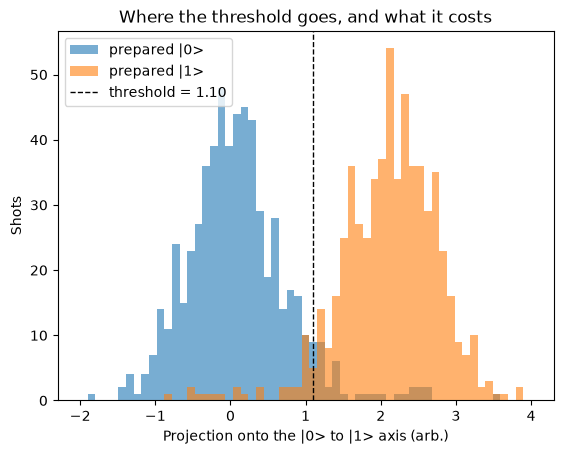

In [19]:
def project(array):
    """Project single shots onto the |0> to |1> axis."""
    z = array.sel(IQ="I").values + 1j * array.sel(IQ="Q").values
    return ((z - GROUND) * np.conj(AXIS)).real


shots = np.concatenate([project(ground), project(excited)])
prepared = np.concatenate([np.zeros(ground.sizes["shot"]), np.ones(excited.sizes["shot"])])
threshold = 0.5 * (shots[prepared == 0].mean() + shots[prepared == 1].mean())
decided = (shots > threshold).astype(float)

separation = shots[truth == 1].mean() - shots[truth == 0].mean()
sigma = 0.5 * (shots[truth == 0].std() + shots[truth == 1].std())
print(f"blob separation  = {separation / sigma:.1f} sigma")
print(f"threshold        = {threshold:+.3f}")
print(f"measured error   = {100 * (decided != prepared).mean():.1f}%  (readout plus preparation)")
print(f"assignment error = {100 * (decided != truth).mean():.1f}%  (readout alone)")
print(f"gaussian estimate= {100 * 0.5 * math.erfc(separation / (2 * np.sqrt(2) * sigma)):.1f}%")

bins = np.linspace(-2.0, 4.0, 60)
plt.hist(shots[prepared == 0], bins=bins, alpha=0.6, label="prepared |0>")
plt.hist(shots[prepared == 1], bins=bins, alpha=0.6, label="prepared |1>")
plt.axvline(threshold, color="k", ls="--", lw=1, label=f"threshold = {threshold:.2f}")
plt.xlabel("Projection onto the |0> to |1> axis (arb.)")
plt.ylabel("Shots")
plt.title("Where the threshold goes, and what it costs")
plt.legend()
plt.show()

## 4.7 Active reset: using a shot to decide

A qubit does not start cold. Waiting for it costs several T1 per shot, which is most of your
measurement time. Active reset does the fast thing. Measure, and fire a pi pulse only if the qubit
came up excited.

`if_` / `elif_` / `else_` are context managers, and they chain exactly like Python's. The
condition is a **measurement-state predicate**, nothing wider yet:

| shape | reads as |
|---|---|
| `m.state == 1` | this measurement classified as excited |
| `m.state != 0` | the same thing, spelled the other way |
| `m1.state == m2.state` | two measurements agreed |
| `qp.eq(m.state, 0)` | the helper form, for building conditions programmatically |

Three rules, enforced in two places. The condition has to be a measurement-state predicate. Pass
anything else and the builder raises on the spot. `elif_` and `else_` have to come **immediately**
after their arm, because anything appended in between closes the chain, and that raises too. The
third one waits for `validate`: every measurement you reference must have asked for `MF.STATE`. A
condition on a classification nobody computed is a diagnostic, not a guess.

In [20]:
oops = qp.QProgram(schema=schema)
m_no_state = oops.measure(q[0].readout, "readout", "weights")  # default fields=(MF.IQ,)
with oops.if_(m_no_state.state == 1):
    oops.play(q[0].drive, "pi")
for diagnostic in qp.validate(oops, qp.reference_capabilities())[0]:
    print(f"[{diagnostic.severity}] {diagnostic.code}: {diagnostic.message}")

bad = qp.QProgram(schema=schema)
counter = bad.variable("counter")
try:
    with bad.if_(counter > 3):  # not a measurement-state predicate
        bad.play(q[0].drive, "pi")
except qp.ValidationError as exc:
    print("ValidationError:", exc)

[error] missing-classification: Conditional references q0/readout/m0.state, but the measurement does not request state classification (add MeasurementField.STATE to fields=)
ValidationError: if_() condition must reference at least one measurement-state ref (e.g. `handle.state`); got a comparison of Variable and Constant


Now the fake qubit. The reference executor does not simulate the pi pulse, so the model has to
keep the bookkeeping itself: a fresh shot starts hot with probability `p_hot`, and the *second*
measurement of a shot happens after the reset attempt, which lands the qubit in the ground state
unless the pulse missed.

That is a stand-in, and it is the only part of this section that is. The program, the conditional,
the NaN handling, and the arithmetic at the end are the real thing.

In [21]:
class ResetModel:
    """A qubit that is sometimes born hot, and a reset pulse that usually works."""

    raw_samples = 16

    def __init__(self, p_hot=0.18, pi_error=0.03, sigma=0.3, seed=11):
        self.p_hot, self.pi_error, self.sigma = p_hot, pi_error, sigma
        self.rng = np.random.default_rng(seed)
        self.shot, self.excited = None, 0

    def sample(self, bus, env):
        if env["shot"] != self.shot:  # a new shot: the qubit arrives however it arrives
            self.shot, self.excited = env["shot"], int(self.rng.random() < self.p_hot)
        elif self.excited:  # a later measurement in the same shot: the pi pulse has fired
            self.excited = int(self.rng.random() < self.pi_error)
        center = EXCITED if self.excited else GROUND
        return qp.MeasurementSample(
            i=center.real + self.rng.normal(0, self.sigma),
            q=center.imag + self.rng.normal(0, self.sigma),
            state=self.excited,
            raw=np.zeros((self.raw_samples, 2)),
        )


# Two looks at the same shot. The second one happens after the reset pulse, by construction.
peek_model = ResetModel(seed=3)
print("shot 0, first look :", peek_model.sample("q0/readout", {"shot": 0.0}).state)
print("shot 0, second look:", peek_model.sample("q0/readout", {"shot": 0.0}).state)

shot 0, first look : 1
shot 0, second look: 0


One more piece of the result contract before the exercise. **A measurement inside a conditional
arm holds NaN wherever the arm did not run.** The averaging is count-based. No executions, no
mean. With single shots on the sweep axis that is easy to see, and it tells you which shots took
which branch.

In [22]:
peek = qp.QProgram(label="nan_demo", schema=schema)
peek_shot = peek.variable("shot")
with peek.sweep(peek_shot, qp.Range(0, 11, 1)):  # 12 shots, small enough to read
    check = peek.measure(q[0].readout, "readout", "weights", name="check", fields=(MF.STATE,))
    with peek.if_(check.state == 1):
        peek.call(x180, q[0].drive, A_PI)
        peek.sync()
        verify = peek.measure(q[0].readout, "readout", "weights", name="verify", fields=(MF.STATE,))

peek_result = qp.simulate(peek, model=ResetModel(seed=0))
print("check :", peek_result.get(check, field=MF.STATE).values)
print("verify:", peek_result.get(verify, field=MF.STATE).values)
print("arm ran on", int(np.isfinite(peek_result.get(verify, field=MF.STATE).values).sum()), "of 12 shots")

check : [0. 1. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0.]
verify: [nan  0. nan nan  0.  0. nan nan nan nan nan nan]
arm ran on 3 of 12 shots


### 🧩 Exercise 4.2: active reset, before and after

Build the reset experiment on 400 single shots and report the excited-state population before and
after the reset.

1. One variable `shot`, swept with `qp.Range(0, 399, 1)`, no `average`.
2. `check = program.measure(..., name="check", fields=(MF.STATE,))`.
3. `with program.if_(check.state == 1):` call `x180`, `sync`, and measure again as `"verify"`.
4. `with program.else_():` do something harmless, `program.wait(q[0].drive, 40)`.
5. Run it with `ResetModel()` and pull both state arrays.
6. The population before is the mean of `check`. For the population after, remember the NaN:
   a cold shot never entered the arm, so its outcome after the reset attempt is what `check`
   already said. `np.where(np.isnan(verify), check, verify)` is the whole calculation.

Expect roughly 18 percent before and 1 percent after: the residual is the shots where the pi pulse
missed. Call the program `reset`, because the cell after your solution prints its `.qp` text.

In [ ]:
# TODO: active reset on 400 single shots.
#
# 1) reset = qp.QProgram(label="active_reset", schema=schema); r_shot = reset.variable("shot")
# 2) with reset.sweep(r_shot, qp.Range(0, 399, 1)):
# 3)     check = reset.measure(..., name="check", fields=(MF.STATE,))
# 4)     with reset.if_(check.state == 1): x180, sync, measure(name="verify", fields=(MF.STATE,))
# 5)     with reset.else_(): reset.wait(q[0].drive, 40)
# 6) reset_result = qp.simulate(reset, model=ResetModel())
# 7) before = ...get(check, field=MF.STATE).values; verified = ...get(verify, ...).values
# 8) after = np.where(np.isnan(verified), before, verified)
#
# Print both populations. Expect about 18% before and 1% after.

In [24]:
print(qp.dumps(reset))

#!QProgram 1.0

metadata:
  label: "active_reset"
  description: "measure, then fix it"

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires

fragment x180(drive, amp):
  play drive IQDrag(amplitude=amp, duration=40, sigma=10, beta=0.1)

body:
  var shot label="Shot index"

  for shot in Range(start=0.0, stop=399.0, step=1.0):
    measure q[0].readout "readout" "weights" name="check" fields=["state"]
    if check.state == 1:
      x180(q[0].drive, 0.62)
      sync
      measure q[0].readout "readout" "weights" name="verify" fields=["state"]
    else:
      wait q[0].drive 40



Read that text once more. The feedback is in the file. `if check.state == 1:` is a statement in a
portable text format, not a vendor call, and that is the point of putting it in the language: the
same intent used to be spelled `program.<vendor>.active_reset(...)`, which locked the experiment
to one rack. A platform with a hand-tuned reset choreography can still recognise the pattern at
compile time and lower it to whatever its sequencer does best.

## Recap and what is next

- A **fragment** is a pulse block with parameters. `@fragment` records the body once, `call`
  appends a node, `expand()` inlines it. Keep `measure` in the host program so the handle stays an
  ordinary variable.
- **T1, T2\*, T2** all came out of the same three moves with a different middle, and all three
  fits landed within a couple of percent of the device. The fringe frequency from Ramsey is the
  correction to your drive frequency.
- One `measure` produces up to three **fields**. `state` is the population, `iq` needs projecting,
  `raw` is the trace. Asking for a field nobody requested raises rather than substituting.
- Dropping `average` and sweeping a **shot index** gives you single shots, which is what a
  threshold gets calibrated on. Separation over cloud width is the whole story.
- **Feedback** is `if_(handle.state == 1)`, with NaN in the arm that did not run, and it
  serializes into the `.qp` file like any other statement.
- Everything so far assumed one rack that can do all of it. Part 5 takes these exact programs to a
  machine where the flux line has no sequencer, and lets the platform tell you what it can run.